# **Data Preparation and Analysis**

## **Introduction**

Preparation and analysis of prostate cancer patient data from RHC-SP to examine factors associated with survival prediction.

## **Imports**

In [ ]:

!pip install scikit-survival --quiet
!pip install shap --quiet
!pip install lifelines --quiet
!pip install category_encoders --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder, StandardScaler, MinMaxScaler, MaxAbsScaler, QuantileTransformer, FunctionTransformer
from category_encoders import TargetEncoder
from sklearn.metrics import roc_curve, roc_auc_score, auc, ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline

from lifelines.statistics import logrank_test
from lifelines import KaplanMeierFitter

from scipy.stats import chi2, chisquare, ks_2samp,entropy

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Functions**

In [ ]:
def preparing_dataset(df):

    df_aux = df.copy()

    # -------------------------
    # Main filters
    # -------------------------
    df_aux = df_aux[
        (df_aux.TOPOGRUP == 'C61') &
        (df_aux.TMO == 0) &
        (df_aux.TMOAPOS == 0) &
        (df_aux.ANODIAG.between(2014, 2019)) &
        (~df_aux.GLEASON.isin([8, 9])) &
        (~df_aux.PSA.isin([8, 9]))
    ]

    # -------------------------
    # IVS Categorization
    # -------------------------
    df_aux[['ivs_infraestrutura_urbana',
            'ivs_capital_humano',
            'ivs_renda_e_trabalho']] = \
    df_aux[['ivs_infraestrutura_urbana',
            'ivs_capital_humano',
            'ivs_renda_e_trabalho']].apply(
       lambda col: [0 if ivs <= 0.2 else
                     1 if ivs <= 0.3 else
                     2 if ivs <= 0.4 else
                     3 if ivs <= 0.5 else
                     4 for ivs in col]
    )

    # -------------------------
    # Distance Categorization
    # -------------------------
    df_aux['DISTANCIA_CARRO'] = [
        0 if d <= 10 else
        1 if d <= 24 else
        2 if d <= 66 else
        3 for d in df_aux.DISTANCIA_CARRO
    ]

    # -------------------------
    # Excluded Columns
    # -------------------------
    drop_cols = [
        'SEXO','CIDADE','DTCONSULT','DTDIAG','DTTRAT','TRATAMENTO',
        'TRATHOSP','TRATFANTES','TRATFAPOS','NENHUM','CIRURGIA','RADIO',
        'QUIMIO','HORMONIO','TMO','IMUNO','OUTROS','NENHUMAPOS',
        'CIRURAPOS','RADIOAPOS','QUIMIOAPOS','HORMOAPOS','TMOAPOS',
        'IMUNOAPOS','OUTROAPOS','DTULTINFO','ULTINFO','FAIXAETAR',
        'DTRECIDIVA','RUA_RESID','UF_RESID','CEP_HOSP','RUA_HOSP',
        'CIDADE_RESID_NORMALIZADA','TEMPO_CARRO','DISTANCIA_TRANSP',
        'TEMPO_TRANSP','CONSDIAG_CAT','PRESENCA_META','PRESENCA_REC','OBITO_CANCER'
    ]

    df_aux = df_aux.drop(columns=drop_cols, errors='ignore')

    return df_aux

# **Database Exploration**

Exploratory analysis performed to assess the dataset structure, identify patterns, and evaluate data quality.

In [ ]:
# Dataset up to 04/2025 with distance, IVS and date data.
!gdown 1fcIz8OXLDBNwpppw_BC4A7MPIEq0MJWh --quiet

df = pd.read_csv('rhc_ceps_final_datas.csv', dtype={'CEP': str,
                                                    'CEP_HOSP': str})

print(df.shape)
df.head(3)

(308911, 74)


,INSTITU,ESCOLARI,IDADE,SEXO,CEP,IBGE,CIDADE,CATEATEND,DTCONSULT,DIAGPREV,...,CONSDIAG_CAT,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,OBITO_GERAL,OBITO_CANCER,ivs_infraestrutura_urbana,ivs_capital_humano,ivs_renda_e_trabalho
0,22128,2,106,1,15520000,3556107.0,VALENTIM GENTIL,2,2023-01-31,2,...,3,0,2,0,1,0,0,0.000,0.249,0.205
1,16411,9,103,2,08061540,3550308.0,SAO PAULO,2,2016-06-23,2,...,3,2,2,0,0,1,0,0.405,0.257,0.212
2,20907,2,103,1,14540000,3520103.0,IGARAPAVA,9,2012-04-20,2,...,3,3,3,0,0,1,1,0.407,0.313,0.234


In [ ]:
df.columns

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'SEXO', 'CEP', 'IBGE', 'CIDADE',
       'CATEATEND', 'DTCONSULT', 'DIAGPREV', 'DTDIAG', 'TOPO', 'TOPOGRUP',
       'MORFO', 'EC', 'ECGRUP', 'PSA', 'GLEASON', 'DTTRAT', 'TRATAMENTO',
       'TRATHOSP', 'TRATFANTES', 'TRATFAPOS', 'NENHUM', 'CIRURGIA', 'RADIO',
       'QUIMIO', 'HORMONIO', 'TMO', 'IMUNO', 'OUTROS', 'NENHUMAPOS',
       'CIRURAPOS', 'RADIOAPOS', 'QUIMIOAPOS', 'HORMOAPOS', 'TMOAPOS',
       'IMUNOAPOS', 'OUTROAPOS', 'DTULTINFO', 'ULTINFO', 'ANODIAG',
       'FAIXAETAR', 'DRS', 'RRAS', 'DTRECIDIVA', 'DSCINST', 'IBGEATEN',
       'DRS_INST', 'RRAS_INST', 'CIDADE_INST', 'BAIRRO_RESID', 'RUA_RESID',
       'UF_RESID', 'CEP_HOSP', 'BAIRRO_HOSP', 'RUA_HOSP', 'HABILIT_HOSP',
       'CIDADE_RESID_NORMALIZADA', 'DISTANCIA_CARRO', 'TEMPO_CARRO',
       'DISTANCIA_TRANSP', 'TEMPO_TRANSP', 'ULTIDIAG', 'CONSDIAG_CAT',
       'TRATCONS_CAT', 'DIAGTRAT_CAT', 'PRESENCA_META', 'PRESENCA_REC',
       'OBITO_GERAL', 'OBITO_CANCER', 'ivs_infraestrutura_ur

## **Feature Analysis**

In [ ]:
df.PSA.value_counts().sort_index()

,count
PSA,
1,24493
2,9363
3,8568
8,265330
9,1157


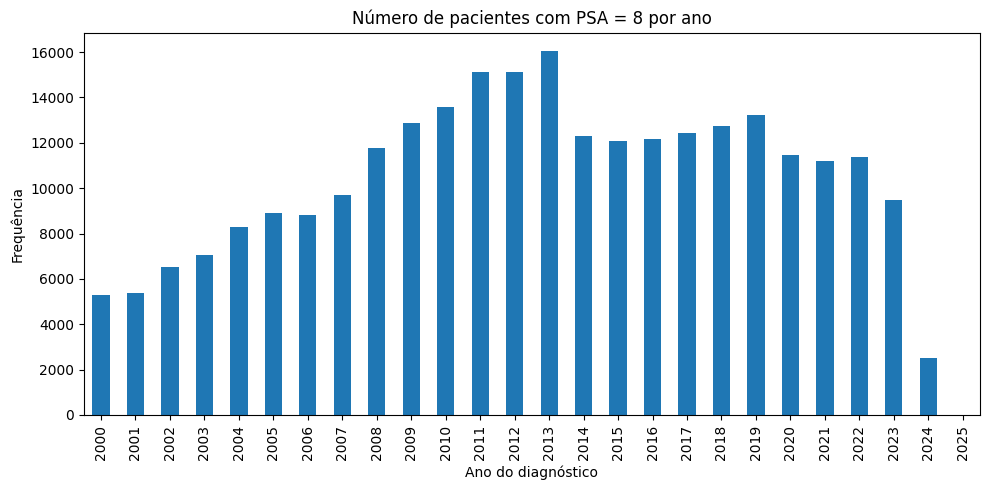

In [ ]:
psa8 = df[df['PSA'] == 8]

freq_ano = psa8['ANODIAG'].value_counts().sort_index()

plt.figure(figsize=(10,5))
freq_ano.plot(kind='bar')

plt.title('Número de pacientes com PSA = 8 por ano')
plt.xlabel('Ano do diagnóstico')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

In [ ]:
df.GLEASON.value_counts().sort_index()

,count
GLEASON,
1,13086
2,19927
3,9579
8,265330
9,989


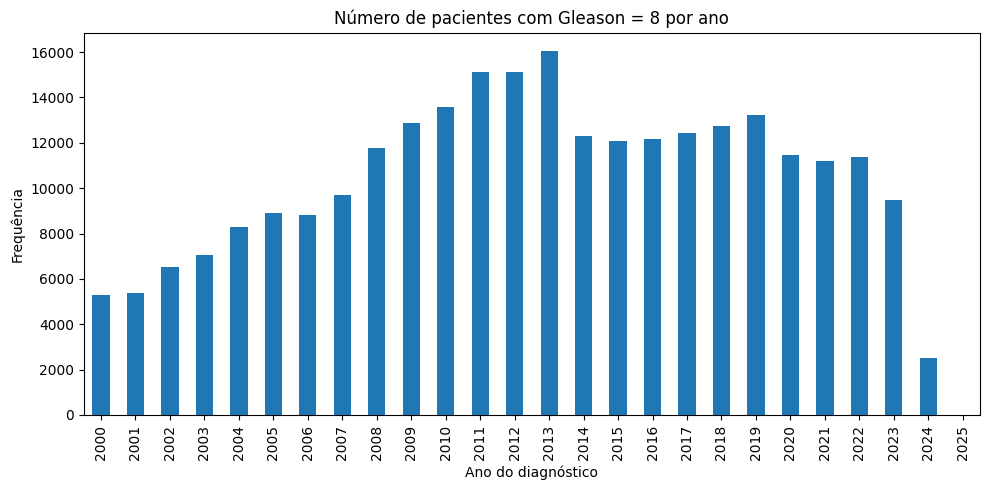

In [ ]:
psa8 = df[df['GLEASON'] == 8]

freq_ano = psa8['ANODIAG'].value_counts().sort_index()

plt.figure(figsize=(10,5))
freq_ano.plot(kind='bar')

plt.title('Número de pacientes com Gleason = 8 por ano')
plt.xlabel('Ano do diagnóstico')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

In [ ]:
# Tipos de câncer presentes no banco
## C18, C19, C20 > Colorretal
## C34 > Pulmão
## C50 > Mama
## C53 > Colo do Útero
## C61 > Próstata
df.TOPOGRUP.value_counts().sort_index()

,count
TOPOGRUP,
C18,31131
C19,4099
C20,23872
C34,34384
C50,107720
C53,22951
C61,84754


In [ ]:
df.TOPO.value_counts().sort_index()

,count
TOPO,
C163,1
C180,2160
C181,403
C182,5097
C183,660
C184,2291
C185,495
C186,2651
C187,9239


In [ ]:
df.ECGRUP.value_counts().sort_index()

,count
ECGRUP,
I,46202
II,115349
III,80428
IV,66932


In [ ]:
df.ANODIAG.value_counts().sort_index()

,count
ANODIAG,
2000,5273
2001,5373
2002,6519
2003,7060
2004,8275
2005,8907
2006,8801
2007,9686
2008,11759


In [ ]:
df.UF_RESID.value_counts().sort_index()

,count
UF_RESID,
SP,285131


In [ ]:
df.CATEATEND.value_counts().sort_index()

,count
CATEATEND,
2,229039
9,79872


In [ ]:
df.HABILIT_HOSP.value_counts().sort_index()

,count
HABILIT_HOSP,
0,55518
1,163371
2,90022


In [ ]:
df.OBITO_GERAL.value_counts().sort_index()

,count
OBITO_GERAL,
0,154712
1,154199


In [ ]:
df.HABILIT_HOSP.value_counts().sort_index()

,count
HABILIT_HOSP,
0,55518
1,163371
2,90022


In [ ]:
df.FAIXAETAR.value_counts().sort_index()

,count
FAIXAETAR,
20-29,3301
30-39,16709
40-49,39724
50-59,68339
60-69,93004
70+,87834


In [ ]:
df.DRS_INST.value_counts().sort_index()

,count
DRS_INST,
1,130302
2,3324
3,4643
4,6464
5,26447
6,39990
7,21436
8,3357
9,7514


# **Preparation and Analysis of Prostate Data**

Step responsible for organizing, cleaning, and transforming raw data into a format suitable for analysis and modeling.

In [ ]:
df_prost = preparing_dataset(df)

print(df_prost.shape)
df_prost.head(3).style.set_sticky(axis="columns")

(28385, 33)


,INSTITU,ESCOLARI,IDADE,CEP,IBGE,CATEATEND,DIAGPREV,TOPO,TOPOGRUP,MORFO,EC,ECGRUP,PSA,GLEASON,ANODIAG,DRS,RRAS,DSCINST,IBGEATEN,DRS_INST,RRAS_INST,CIDADE_INST,BAIRRO_RESID,BAIRRO_HOSP,HABILIT_HOSP,DISTANCIA_CARRO,ULTIDIAG,TRATCONS_CAT,DIAGTRAT_CAT,OBITO_GERAL,ivs_infraestrutura_urbana,ivs_capital_humano,ivs_renda_e_trabalho
44,20737,1,98,14787012,3505500.000000,2,1,C619,C61,85503,IV,IV,3,3,2017,5,RRAS 13,FUND PIO XII,3505500,5,RRAS 13,BARRETOS,Santa Terezinha,Centro,1,0,573,0,0,1,0,1,0
45,10,2,98,17022091,3506003.000000,2,2,C619,C61,81403,III,III,3,2,2019,6,RRAS 09,HOSP ESTADUAL DE BAURU,3506003,6,RRAS 09,BAURU,Pousada da Esperança I,Núcleo Residencial Presidente Geisel,2,1,1828,0,0,0,0,1,0
48,15,2,98,13847176,3530706.000000,2,1,C619,C61,85503,IV,IV,3,3,2016,14,RRAS 15,HOSP MUN TABAJARA RAMOS,3530706,14,RRAS 15,MOGI-GUACU,Jardim Santo Antônio,Jardim Selma,0,0,248,2,2,1,0,1,1


In [ ]:
df_prost.columns

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'CEP', 'IBGE', 'CATEATEND', 'DIAGPREV',
       'TOPO', 'TOPOGRUP', 'MORFO', 'EC', 'ECGRUP', 'PSA', 'GLEASON',
       'ANODIAG', 'DRS', 'RRAS', 'DSCINST', 'IBGEATEN', 'DRS_INST',
       'RRAS_INST', 'CIDADE_INST', 'BAIRRO_RESID', 'BAIRRO_HOSP',
       'HABILIT_HOSP', 'DISTANCIA_CARRO', 'ULTIDIAG', 'TRATCONS_CAT',
       'DIAGTRAT_CAT', 'OBITO_GERAL', 'ivs_infraestrutura_urbana',
       'ivs_capital_humano', 'ivs_renda_e_trabalho'],
      dtype='object')

In [ ]:
# Calculate and Adjust Survival Time in Months
df_prost['meses_diag'] = np.ceil(df_prost['ULTIDIAG']/30).astype(int) # Calculate survival time in months, rounding up

df_prost.loc[df_prost.meses_diag == 0, 'meses_diag'] = 1 # Ensure no survival time is zero (set to 1 month)
df_prost.loc[df_prost.meses_diag > 120, ['meses_diag', 'OBITO_GERAL']] = [121, 0] # Cap survival time at 61 months and set obito_geral to 0 for those exceeding the cap

df_prost.meses_diag.value_counts().sort_index().tail() # Display the value counts for the last few survival times (for checking)

,count
meses_diag,
117,148
118,134
119,112
120,123
121,928


In [ ]:
df_prost.describe().T

,count,mean,std,min,25%,50%,75%,max
INSTITU,28385.0,1.333685e+05,216079.258676,10.0,18961.0,21318.0,207972.0,928940.0
ESCOLARI,28385.0,4.227761e+00,2.841194,1.0,2.0,3.0,5.0,9.0
IDADE,28385.0,6.746655e+01,8.409380,22.0,62.0,67.0,73.0,98.0
IBGE,28385.0,3.533587e+06,17376.210573,3500105.0,3518800.0,3537404.0,3550308.0,3557303.0
CATEATEND,28385.0,2.000000e+00,0.000000,2.0,2.0,2.0,2.0,2.0
DIAGPREV,28385.0,1.771781e+00,0.419692,1.0,2.0,2.0,2.0,2.0
MORFO,28385.0,8.417470e+04,1917.587925,80103.0,81403.0,85503.0,85503.0,90143.0
PSA,28385.0,1.594187e+00,0.787990,1.0,1.0,1.0,2.0,3.0
GLEASON,28385.0,1.870812e+00,0.722857,1.0,1.0,2.0,2.0,3.0
ANODIAG,28385.0,2.016451e+03,1.738193,2014.0,2015.0,2016.0,2018.0,2019.0


In [ ]:
df_prost.describe(include=['object'])

,CEP,TOPO,TOPOGRUP,EC,ECGRUP,RRAS,DSCINST,RRAS_INST,CIDADE_INST,BAIRRO_RESID,BAIRRO_HOSP
count,28385,28385,28385,28385,28385,28385,28385,28385,28385,19723,28266
unique,17314,1,1,5,4,18,60,15,40,4870,48
top,18550000,C619,C61,IIB,II,RRAS 06,ICESP,RRAS 06,SAO PAULO,Centro,Pacaembu
freq,82,28385,28385,8243,15287,6622,3797,10394,10394,526,3797


In [ ]:
path = 'df_prostata.csv'
df_prost.to_csv(path, index=False)

# **Results**

### Selections made:
- Patients with complete information for the 'GLEASON' and 'PSA' variables;
- Patients diagnosed between 2014 and 2019;
- Patients who did not undergo bone marrow transplantation;
- Topography categorized as ICD-10 C61.

### Initial Database size:
308911 pacients
### Final database size:
28385 pacients

### Resulting Dataset:
`1ZSljungAYB8ElWTk3ZNNnO3KAxgAgc8h`
